<a href="https://colab.research.google.com/github/jcdumlao14/ESS11e04_1_DataAnalysis/blob/main/Analyzing_the_Health_and_Well_being.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

import warnings
warnings.filterwarnings("ignore")

# **GLOBAL VISUAL STYLE**


In [2]:
# GLOBAL VISUAL STYLE (PRO LEVEL)

#sns.set_theme(style="whitegrid")

main_palette = sns.color_palette("viridis")
warm_palette = sns.color_palette("magma")
cool_palette = sns.color_palette("crest")

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.edgecolor': '#dddddd',
    'axes.labelcolor': '#333333',
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    #'grid.color': '#cccccc',
    #'grid.linestyle': '--',
    #'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans'
})

plt.rcParams['axes.grid'] = False

# **LOAD DATA**

In [3]:
# LOAD DATA FROM ZIP

zip_path = '/content/ESS11e04_1.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files found in ZIP:", z.namelist())

    with z.open('ESS11e04_1.csv') as f:
        df_raw = pd.read_csv(f, low_memory=False)

print("\nRaw dataset shape:", df_raw.shape)

Files found in ZIP: ['ESS11e04_1.csv', 'ESS11e04_1 codebook.html']

Raw dataset shape: (50116, 691)


## **FILTER DATA**

- **Data Filtering:** The raw dataset was narrowed down to focus specifically on the working-age population (adults aged 18 to 65) who are currently in paid work. This ensures the results reflect a specific economic demographic.


In [4]:
# FILTER DATA

df = df_raw[
    (df_raw['pdwrk'] == 1) &
    (df_raw['agea'] >= 18) &
    (df_raw['agea'] <= 65)
].copy()

print("Filtered dataset shape:", df.shape)

Filtered dataset shape: (25499, 691)


In [5]:
df.head()

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
2,ESS11e04_1,11,4.1,12.01.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
5,ESS11e04_1,11,4.1,12.01.2026,50158,AT,0.992605,1.392813,0.330915,0.460902,...,NaN,2023-10-16 09:42:52,2023-10-16 09:38:14,2023-10-16 09:42:52,57.0,1,2.0,0.000691,7,373
8,ESS11e04_1,11,4.1,12.01.2026,50213,AT,1.364956,0.693635,0.330915,0.229534,...,NaN,2023-09-09 15:59:13,2023-09-09 15:57:18,2023-09-09 15:59:13,40.0,1,2.0,0.000502,62,108
10,ESS11e04_1,11,4.1,12.01.2026,50236,AT,0.698986,0.355207,0.330915,0.117543,...,NaN,2023-11-03 12:21:48,2023-11-03 12:17:21,2023-11-03 12:21:48,24.0,1,3.0,0.000981,26,622
12,ESS11e04_1,11,4.1,12.01.2026,50240,AT,0.873454,0.276816,0.330915,0.091602,...,NaN,2023-09-30 11:08:18,2023-09-30 11:06:59,2023-09-30 11:08:18,47.0,1,2.0,0.000785,100,270


# **REGION MAPPING**

- **Categorization:** Country codes were mapped to full names and broader geographic regions (North, South, East, West) to allow for comparative analysis.

In [6]:
# REGION MAPPING

region_map = {
    'NO': 'North', 'SE': 'North', 'DK': 'North', 'FI': 'North', 'IS': 'North', 'GB': 'North', 'IE': 'North',
    'FR': 'West', 'BE': 'West', 'NL': 'West', 'LU': 'West', 'DE': 'West', 'AT': 'West',
    'ES': 'South', 'PT': 'South', 'IT': 'South', 'GR': 'South', 'CY': 'South', 'MT': 'South',
    'PL': 'East', 'CZ': 'East', 'SK': 'East', 'HU': 'East', 'RO': 'East', 'BG': 'East', 'SI': 'East', 'HR': 'East'
}

def get_region(code):
    if pd.isna(code):
        return 'Unknown'
    return region_map.get(str(code).upper(), 'Unknown')

df['region'] = df['cntry'].apply(get_region)


# **COUNTRY NAME MAPPING**

In [7]:
# COUNTRY NAME MAPPING

country_names = {
    'NO': 'Norway', 'SE': 'Sweden', 'DK': 'Denmark', 'FI': 'Finland',
    'IS': 'Iceland', 'GB': 'United Kingdom', 'IE': 'Ireland',
    'FR': 'France', 'BE': 'Belgium', 'NL': 'Netherlands', 'LU': 'Luxembourg',
    'DE': 'Germany', 'AT': 'Austria',
    'ES': 'Spain', 'PT': 'Portugal', 'IT': 'Italy', 'GR': 'Greece',
    'CY': 'Cyprus', 'MT': 'Malta',
    'PL': 'Poland', 'CZ': 'Czech Republic', 'SK': 'Slovakia',
    'HU': 'Hungary', 'RO': 'Romania', 'BG': 'Bulgaria',
    'SI': 'Slovenia', 'HR': 'Croatia'
}

df['country_name'] = df['cntry'].map(country_names)

# **VARIABLE DEFINITIONS**

In [8]:
# VARIABLE DEFINITIONS
variable_definitions = {
    'pdwrk': 'Paid work',
    'wkhtot': 'Total hours worked',
    'stfjb': 'Job satisfaction',
    'wrkhome': 'Work from home',
    'hincfel': 'Household income feeling',
    'stflife': 'Life satisfaction',
    'happy': 'Happiness',
    'health': 'Self-rated health',
    'hltprhc': 'Heart problems',
    'gndr': 'Gender',
    'agea': 'Age'
}

available_vars = [v for v in variable_definitions if v in df.columns]

print("\nVariables found:", available_vars)



Variables found: ['pdwrk', 'wkhtot', 'hincfel', 'stflife', 'happy', 'health', 'hltprhc', 'gndr', 'agea']


# **CLEAN DATA**

- **Data Cleaning:** Numeric values representing **"refusal"** or **"no answer"** were removed to ensure the statistical averages were accurate.

In [9]:
# CLEAN DATA

missing_codes = [7, 8, 9, 77, 88, 99, 777, 888, 999]

for col in available_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(missing_codes, np.nan)

# **Visualization:**
The data was visualized using bar charts for comparisons between countries and histograms/density plots to show the spread of individual characteristics like age, work hours, and happiness.

## **Participant Demographics (Respondents by Country & Region)**
- **Country Distribution:** The study includes a diverse group of over 25,000 respondents. Greece provided the highest number of participants (over 1,500), while Cyprus had the fewest.
- **Regional Balance:** Aside from a large **"Unknown"** group, the distribution across Western, Eastern, Southern, and Northern Europe is relatively even, ranging between 4,500 and 5,200 respondents per region.

# **COUNTRY DISTRIBUTION**




--- COUNTRY COUNTS ---
country_name
Greece            1561
Germany           1370
Italy             1317
Hungary           1209
Austria           1117
Bulgaria          1083
Netherlands       1011
Spain              941
Ireland            920
France             918
Norway             813
United Kingdom     801
Finland            788
Belgium            788
Poland             746
Slovakia           741
Portugal           715
Croatia            690
Slovenia           655
Sweden             646
Iceland            551
Cyprus             324
Name: count, dtype: int64


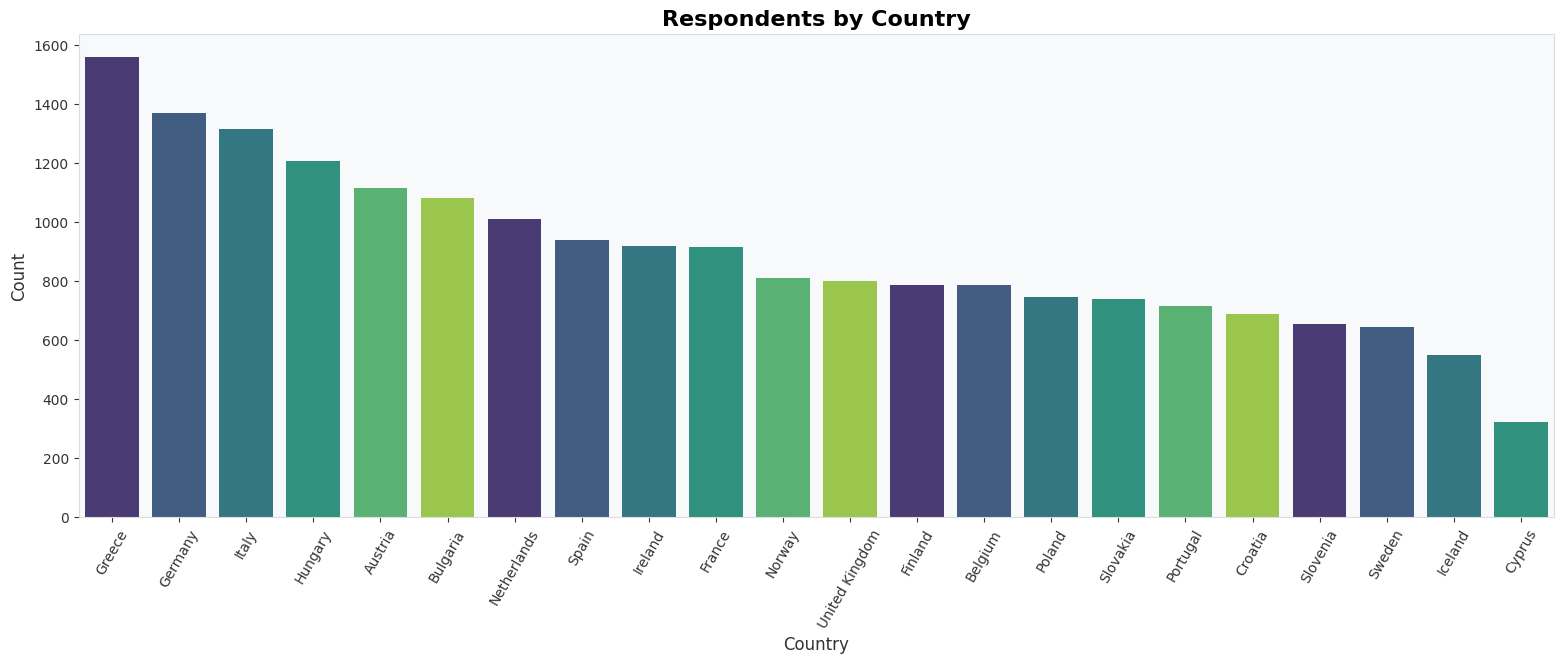

In [10]:
# COUNTRY DISTRIBUTION

country_counts = df['country_name'].value_counts()

print("\n--- COUNTRY COUNTS ---")
print(country_counts)

plt.figure(figsize=(16,7))
sns.barplot(x=country_counts.index, y=country_counts.values, palette=main_palette)

plt.title("Respondents by Country")
plt.xticks(rotation=60)
plt.ylabel("Count")
plt.xlabel("Country")
#plt.grid(axis='y')

plt.tight_layout(pad=2)
plt.savefig("country_distribution.png", dpi=300)
plt.show()

# REGION DISTRIBUTION


--- REGION COUNTS ---
region
Unknown    5794
West       5204
East       5124
South      4858
North      4519
Name: count, dtype: int64


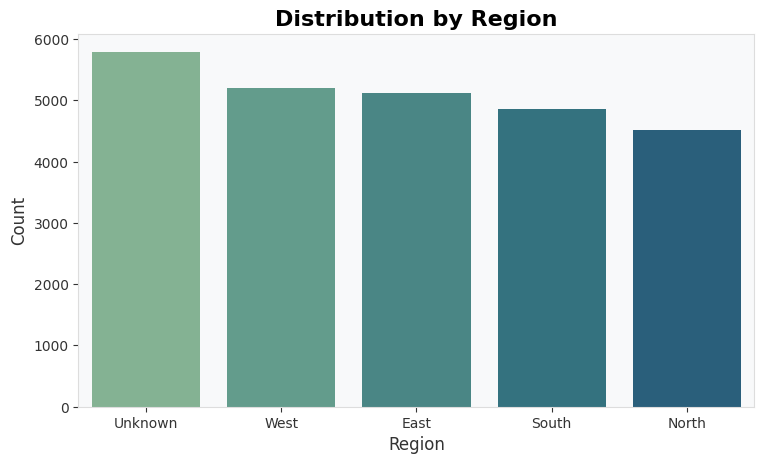

In [11]:
#  REGION DISTRIBUTION

region_counts = df['region'].value_counts()

print("\n--- REGION COUNTS ---")
print(region_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=region_counts.index, y=region_counts.values, palette=cool_palette)

plt.title("Distribution by Region")
plt.ylabel("Count")
plt.xlabel("Region")
#plt.grid(axis='y')

plt.tight_layout(pad=2)
plt.savefig("region_distribution.png", dpi=300)
plt.show()

# **VARIABLE PLOTS**

**Top Row: Employment and Finances**
- **Paid work (pdwrk):** This plot shows a single tall bar, confirming that the entire analyzed group consists of individuals currently in paid employment (represented by the value **"1"**).
- **Total hours worked (wkhtot):** This histogram shows a massive spike at 40 hours. This indicates that the vast majority of respondents work a standard full-time week, with smaller clusters working part-time or extended hours.
- **Household income feeling (hincfel):** This chart measures how people feel about their income. Most respondents fall into categories 1 and 2 (likely meaning they are living comfortably or **"getting by"**), while very few report finding it difficult to manage (categories 3 and 4).

**Middle Row: Personal Well-being**
- **Life satisfaction (stflife):** Measured on a 0–10 scale, most people report a score of 5 or higher. There is a notable **"double peak"** where many people feel moderately satisfied (5-7) and a large group feels completely satisfied (10).
- **Happiness (happy):** Similar to life satisfaction, happiness is skewed toward the high end of the scale. A very large number of respondents rated their happiness as a **"10,"** suggesting a high level of general morale among workers.
- **Self-rated health (health):** Most respondents rated their health as category 1 or 2 (typically representing **"Very Good" or "Good"**). Very few people in this working-age group rated their health as poor (categories 4 and 5).

**Bottom Row: Demographics and Health**
- **Heart problems (hltprhc):** This plot shows two bars: **"0"** (No) and **"1"** (Yes). The overwhelming majority of the workforce does not have heart problems, with only a small fraction reporting a diagnosis.
- **Gender (gndr):** This bar chart shows two nearly equal bars, indicating that the study has a very balanced representation of men and women.
- **Age (agea):** This distribution covers workers from age 18 to 65. The curve shows a **"plateau"** effect, meaning there is a steady and even representation of workers across most age groups, with a slight peak in the 40–55 age range.

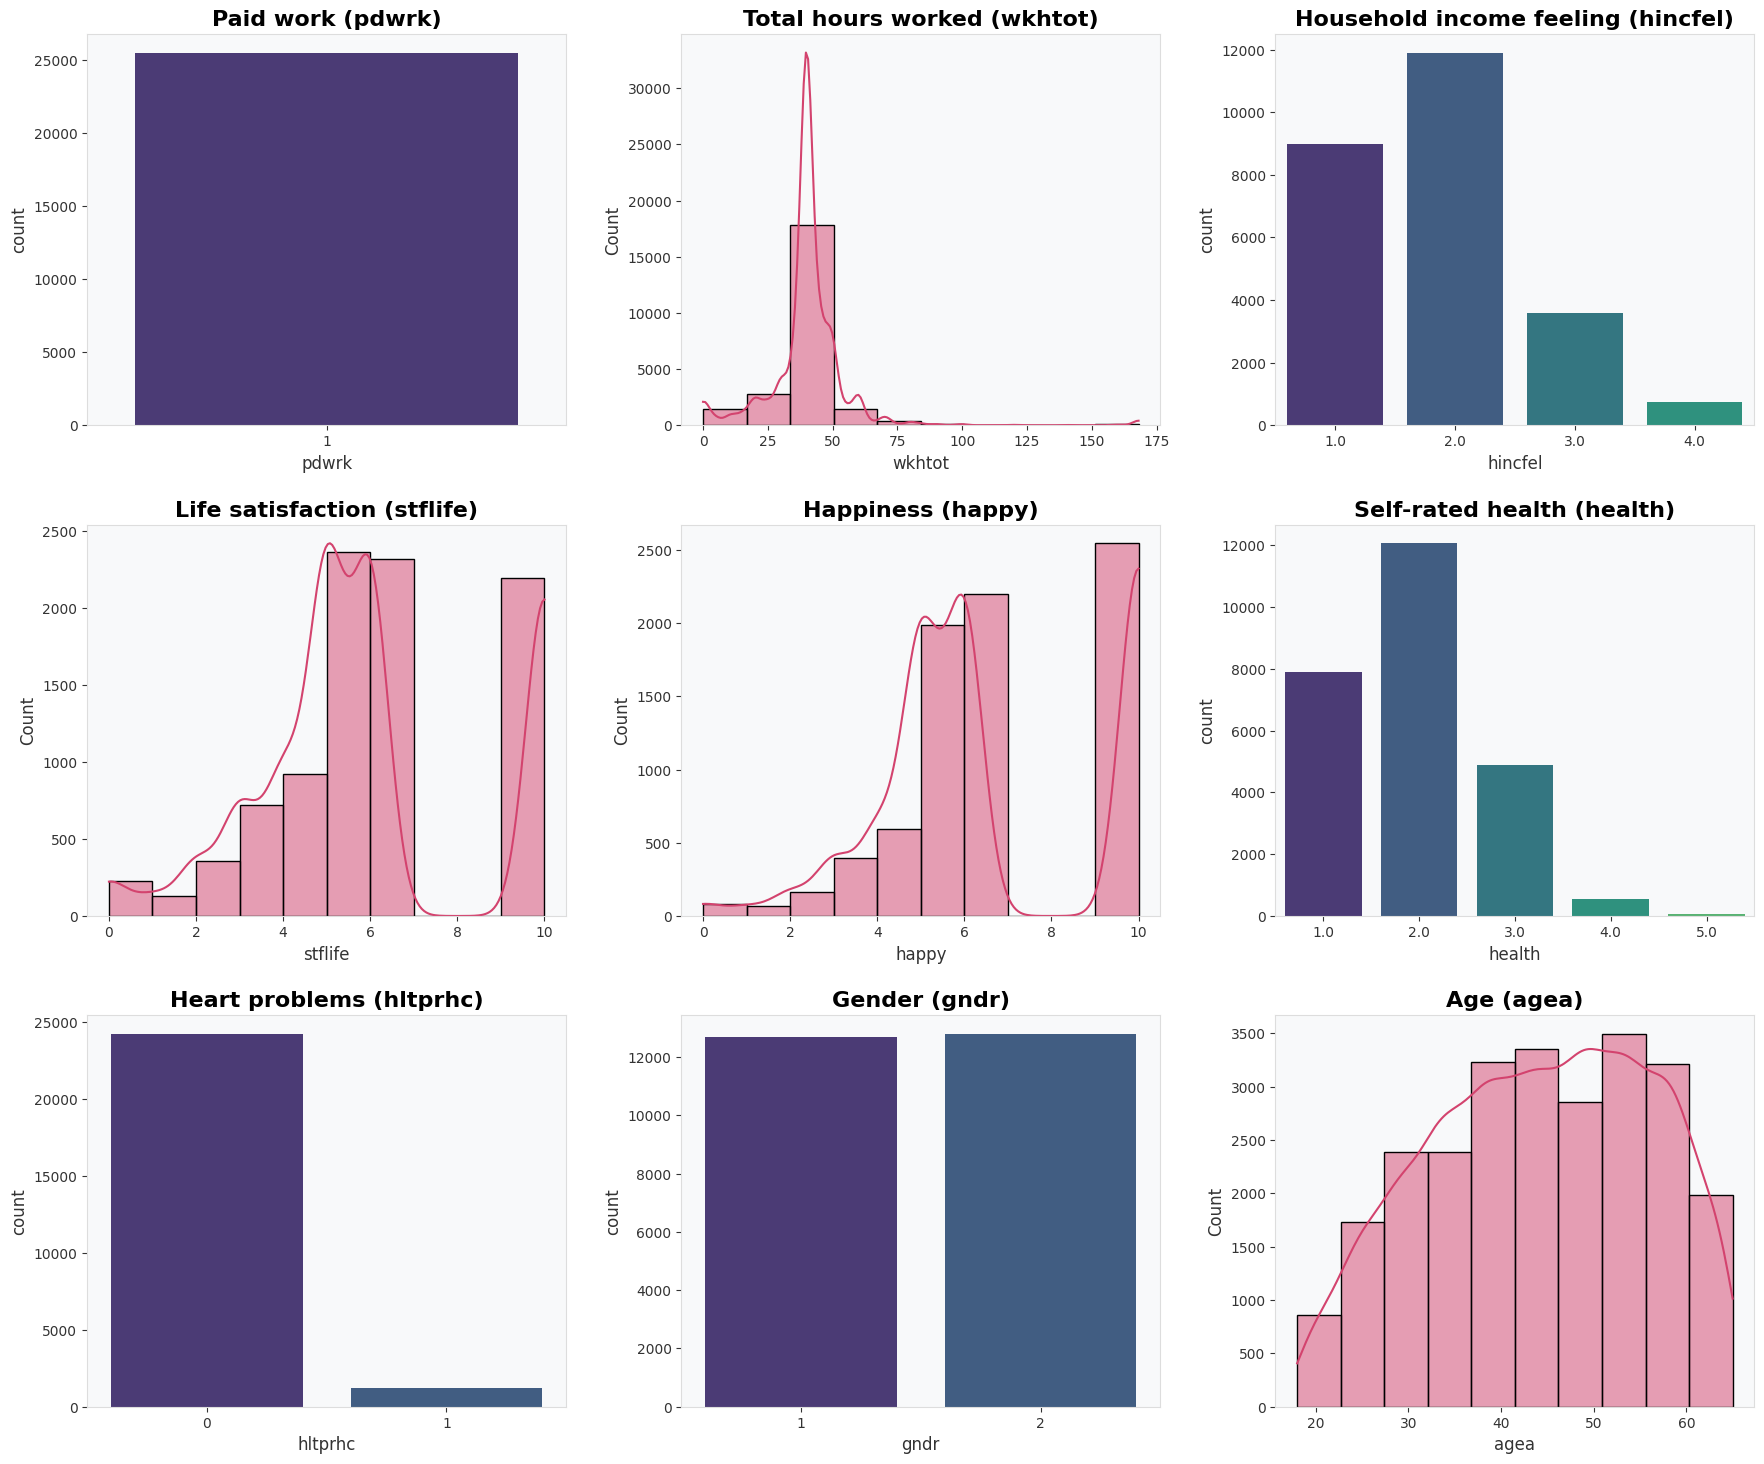

In [12]:
# VARIABLE PLOTS

num_plots = len(available_vars)
cols = 3
rows = (num_plots // cols) + (num_plots % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(available_vars):
    if df[var].nunique() <= 5:
        sns.countplot(x=var, data=df, ax=axes[i], palette=main_palette)
    else:
        sns.histplot(df[var], bins=10, kde=True, ax=axes[i], color=warm_palette[3])

    axes[i].set_title(f"{variable_definitions[var]} ({var})")

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2)
plt.savefig("all_variables_distribution.png", dpi=300)
plt.show()

## **SUMMARY TABLE**

In [13]:
# SUMMARY TABLE

summary_table = df[available_vars].describe().T[['count', 'mean', 'std']]

print("\n--- STATISTICAL SUMMARY ---")
print(summary_table)



--- STATISTICAL SUMMARY ---
           count       mean        std
pdwrk    25499.0   1.000000   0.000000
wkhtot   24234.0  40.258439  16.457296
hincfel  25226.0   1.844327   0.769015
stflife   9245.0   5.886966   2.649242
happy     8037.0   6.538136   2.585125
health   25477.0   1.933783   0.779338
hltprhc  25499.0   0.048982   0.215835
gndr     25499.0   1.501784   0.500007
agea     25499.0  44.063414  11.814298


# **CVD BY COUNTRY**

**Heart Problems (CVD) by Country**
- **Low Prevalence Overall:** The **"Heart Problems"** plot shows that the vast majority of the working population (over 95%) does not have heart issues.
- **Geographic Variation:** This is the most significant finding. There is a clear disparity in heart health across Europe:
   - **Lowest Rates:** Respondents in **Greece and Italy** reported the lowest average frequency of heart problems.
   - **Highest Rates:** Respondents in **Germany** reported the highest average frequency (nearly 9%), significantly higher than the Mediterranean countries.
  - **Trend:** **Northern and Central European** countries generally show higher mean rates of heart problems compared to Southern European countries within this working-age group.


--- CVD RATE PER COUNTRY ---
country_name
Greece            0.016015
Italy             0.016705
Cyprus            0.030864
Hungary           0.032258
Slovakia          0.033738
United Kingdom    0.034956
Ireland           0.035870
Sweden            0.038700
Croatia           0.040580
Austria           0.042077
Portugal          0.044755
Norway            0.045510
Spain             0.046759
Netherlands       0.047478
France            0.050109
Slovenia          0.051908
Bulgaria          0.052632
Finland           0.054569
Belgium           0.055838
Poland            0.057641
Iceland           0.063521
Germany           0.091241
Name: hltprhc, dtype: float64


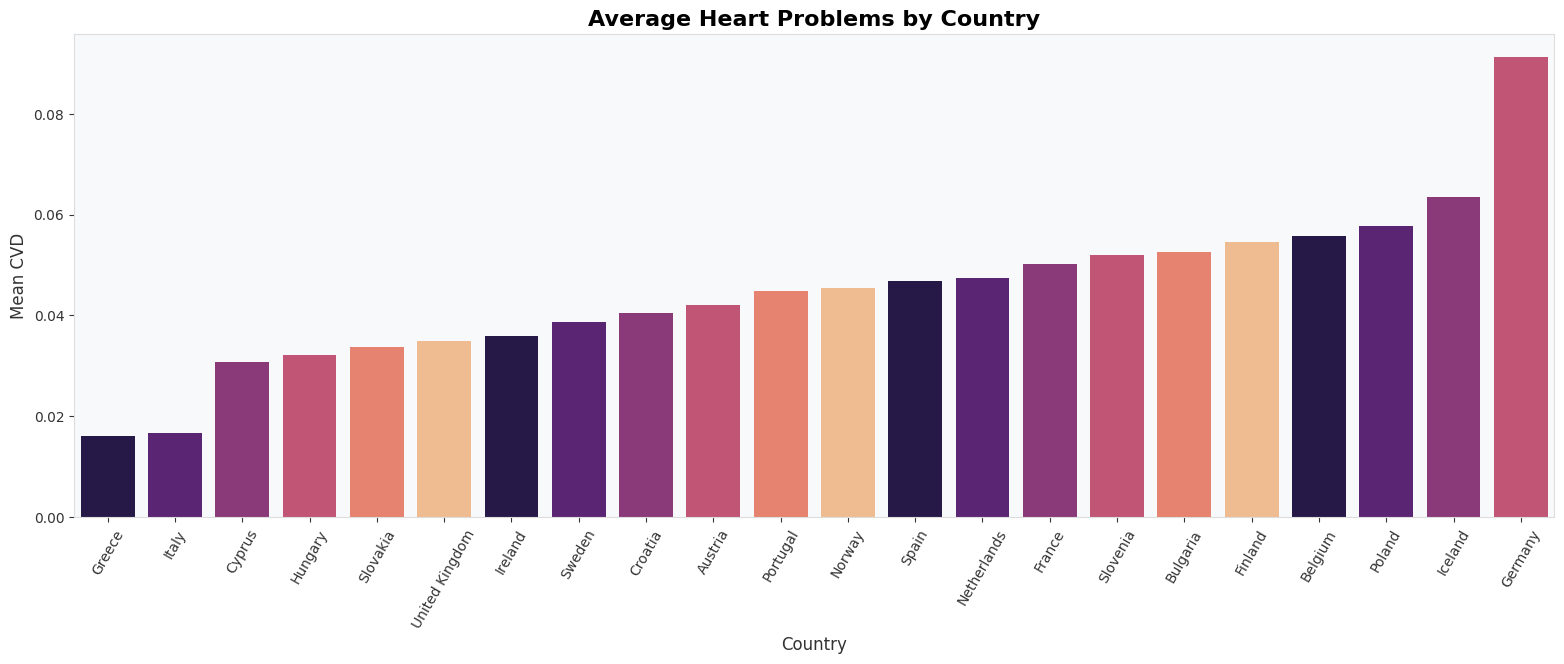

In [14]:
# CVD BY COUNTRY

if 'hltprhc' in df.columns:
    cvd_by_country = df.groupby('country_name')['hltprhc'].mean().sort_values()

    print("\n--- CVD RATE PER COUNTRY ---")
    print(cvd_by_country)

    plt.figure(figsize=(16,7))
    sns.barplot(x=cvd_by_country.index, y=cvd_by_country.values, palette=warm_palette)

    plt.title("Average Heart Problems by Country")
    plt.xticks(rotation=60)
    plt.ylabel("Mean CVD")
    plt.xlabel("Country")

    plt.tight_layout(pad=2)
    plt.savefig("cvd_by_country.png", dpi=300)
    plt.show()